In [13]:
# ==============================================================================
# ENSEMBLE CREDIT RISK ASSESSMENT: ML + ACO + ANFIS + QP BENCHMARK
# ==============================================================================

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from scipy.optimize import minimize
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.base import clone
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, precision_recall_curve

In [14]:
# ==============================================================================
# [Block 1] Data Ingestion & Splitting
# ==============================================================================
print("--- BLOCK 1: DATA INGESTION & STRICT SPLITTING ---")
data = fetch_openml(name='credit-g', version=1, as_frame=True, parser='auto')
X = data.data
y = data.target.map({'good': 0, 'bad': 1}).values.astype(int)

X_train, X_test, y_train_array, y_test_array = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

print(f"Data securely partitioned. Train: {X_train.shape}, Test: {X_test.shape}")

--- BLOCK 1: DATA INGESTION & STRICT SPLITTING ---
Data securely partitioned. Train: (800, 20), Test: (200, 20)


In [15]:
# ==============================================================================
# [Block 2] Leakage-Free OOF Generation via Isolated Pipelines
# ==============================================================================
print("\n--- BLOCK 2: BASE MODELS & OUT-OF-FOLD PREDICTIONS ---")
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X_train.select_dtypes(include=['category', 'object']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_cols)
    ])

base_models = {
    'Logistic_Regression': Pipeline([('prep', clone(preprocessor)), ('clf', LogisticRegression(max_iter=1000, random_state=42))]),
    'SVM': Pipeline([('prep', clone(preprocessor)), ('clf', SVC(kernel='rbf', probability=True, random_state=42))]),
    'MLP': Pipeline([('prep', clone(preprocessor)), ('clf', MLPClassifier(hidden_layer_sizes=(64,), activation='relu', solver='adam', max_iter=1000, random_state=42))])
}

K = 5
skf = StratifiedKFold(n_splits=K, shuffle=True, random_state=42)
N_train = X_train.shape[0]
oof_P_train = np.zeros((N_train, len(base_models)))

for i, (name, model_pipeline) in enumerate(base_models.items()):
    oof_preds = np.zeros(N_train)
    for train_idx, val_idx in skf.split(X_train, y_train_array):
        X_fold_train, y_fold_train = X_train.iloc[train_idx], y_train_array[train_idx]
        X_fold_val = X_train.iloc[val_idx]

        model_pipeline.fit(X_fold_train, y_fold_train)
        oof_preds[val_idx] = model_pipeline.predict_proba(X_fold_val)[:, 1]

    oof_P_train[:, i] = oof_preds
    model_pipeline.fit(X_train, y_train_array)
    print(f"  {name:20s} - OOF ROC-AUC: {roc_auc_score(y_train_array, oof_preds):.4f}")


--- BLOCK 2: BASE MODELS & OUT-OF-FOLD PREDICTIONS ---
  Logistic_Regression  - OOF ROC-AUC: 0.7723
  SVM                  - OOF ROC-AUC: 0.7828
  MLP                  - OOF ROC-AUC: 0.7338


In [16]:
# ==============================================================================
# [Block 3] Mathematical Optimization (QP Benchmark on OOF)
# ==============================================================================
print("\n--- BLOCK 3: QUADRATIC PROGRAMMING BENCHMARK ---")
Q = 2 * np.dot(oof_P_train.T, oof_P_train)
c = -2 * np.dot(oof_P_train.T, y_train_array.astype(float).reshape(-1, 1)).flatten()

def qp_objective(w, Q, c):
    return 0.5 * np.dot(w.T, np.dot(Q, w)) + np.dot(c.T, w)

constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0})
bounds = tuple((0.0, 1.0) for _ in range(oof_P_train.shape[1]))
w_init = np.ones(oof_P_train.shape[1]) / oof_P_train.shape[1]

result = minimize(fun=qp_objective, x0=w_init, args=(Q, c), method='SLSQP', bounds=bounds, constraints=constraints, options={'ftol': 1e-9})
assert result.success, f"QP failed to converge: {result.message}"

w_QP = np.clip(result.x, 0.0, 1.0)
w_QP /= w_QP.sum()

oof_preds_QP = np.dot(oof_P_train, w_QP)
mse_optimal = np.mean((oof_preds_QP - y_train_array) ** 2)
print(f"Optimal QP Weights found.")


--- BLOCK 3: QUADRATIC PROGRAMMING BENCHMARK ---
Optimal QP Weights found.



--- BLOCK 4: ANT COLONY OPTIMIZATION ---
OOF MSE — QP Optimal: 0.163886 | ACO Swarm: 0.163886
ACO Weights converged. L2 Distance to QP Optimal: 0.000002

Weight Comparison:
  Model                        QP      ACO
  Logistic_Regression      0.2792   0.2792
  SVM                      0.7208   0.7208
  MLP                      0.0000   0.0000

Initial Swarm MSE: 0.164222 → Final MSE: 0.163886 | Reduction: 0.2%


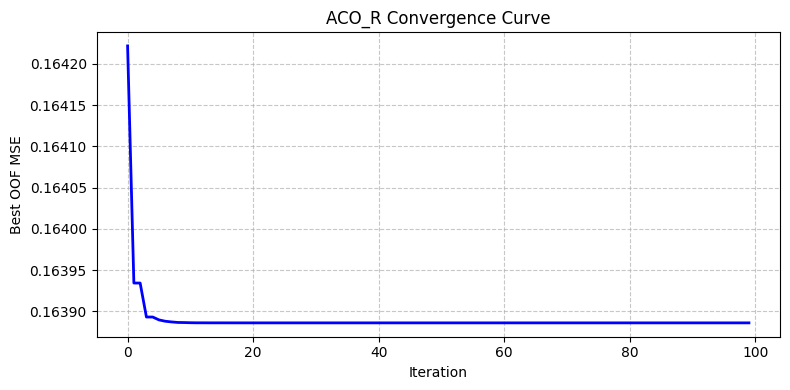

In [17]:
# ==============================================================================
# [Block 4] Swarm Intelligence (Continuous ACO on OOF)
# ==============================================================================
print("\n--- BLOCK 4: ANT COLONY OPTIMIZATION ---")
def map_to_simplex_softmax(w):
    w_stable = w - np.max(w)
    exp_w = np.exp(w_stable)
    return exp_w / np.sum(exp_w)

def objective_function(w, P_oof, y_train):
    w_simplex = map_to_simplex_softmax(w)
    return np.mean((np.dot(P_oof, w_simplex) - y_train) ** 2)

def run_acor(P, y, num_models, n_ants=40, archive_size=20, iterations=100, q=0.1, xi=0.85, seed=42):
    rng = np.random.default_rng(seed)
    archive = rng.standard_normal((archive_size, num_models))
    scores = np.array([objective_function(w, P, y) for w in archive])

    sort_idx = np.argsort(scores)
    archive, scores = archive[sort_idx], scores[sort_idx]

    ranks = np.arange(1, archive_size + 1)
    weights = (1 / (q * archive_size * np.sqrt(2 * np.pi))) * np.exp(-((ranks - 1)**2) / (2 * (q * archive_size)**2))
    selection_probs = weights / np.sum(weights)
    convergence_curve = np.zeros(iterations)

    for iteration in range(iterations):
        new_solutions = np.zeros((n_ants, num_models))
        new_scores = np.zeros(n_ants)

        for ant in range(n_ants):
            guide_idx = rng.choice(archive_size, p=selection_probs)
            guide_solution = archive[guide_idx]
            sigma = xi * np.sum(np.abs(archive - guide_solution), axis=0) / (archive_size - 1)
            sigma = np.maximum(sigma, 1e-6)

            sampled_w = rng.normal(loc=guide_solution, scale=sigma)
            new_solutions[ant] = sampled_w
            new_scores[ant] = objective_function(sampled_w, P, y)

        combined_archive = np.vstack((archive, new_solutions))
        combined_scores = np.concatenate((scores, new_scores))

        sort_idx = np.argsort(combined_scores)
        archive, scores = combined_archive[sort_idx][:archive_size], combined_scores[sort_idx][:archive_size]
        convergence_curve[iteration] = scores[0]

    return archive[0], scores[0], convergence_curve

y_train_float = y_train_array.astype(float)
w_ACO_raw, _, convergence = run_acor(oof_P_train, y_train_float, num_models=oof_P_train.shape[1])
w_ACO = map_to_simplex_softmax(w_ACO_raw)

mse_ACO_comparable = np.mean((np.dot(oof_P_train, w_ACO) - y_train_float) ** 2)
print(f"OOF MSE — QP Optimal: {mse_optimal:.6f} | ACO Swarm: {mse_ACO_comparable:.6f}")
print(f"ACO Weights converged. L2 Distance to QP Optimal: {np.linalg.norm(w_QP - w_ACO):.6f}")

model_names = list(base_models.keys())
print(f"\nWeight Comparison:")
print(f"  {'Model':<22} {'QP':>8} {'ACO':>8}")
for name, wq, wa in zip(model_names, w_QP, w_ACO):
    print(f"  {name:<22} {wq:>8.4f} {wa:>8.4f}")

print(f"\nInitial Swarm MSE: {convergence[0]:.6f} → Final MSE: {convergence[-1]:.6f} | Reduction: {(1 - convergence[-1]/convergence[0])*100:.1f}%")
plt.figure(figsize=(8, 4))
plt.plot(convergence, color='blue', linewidth=2)
plt.xlabel("Iteration")
plt.ylabel("Best OOF MSE")
plt.title("ACO_R Convergence Curve")
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
# plt.show() # Uncomment when running in an interactive environment

In [18]:
# ==============================================================================
# [Block 5] Independent F1-Score Threshold Calibration
# ==============================================================================
print("\n--- BLOCK 5: DECISION THRESHOLD CALIBRATION ---")
oof_preds_ACO = np.dot(oof_P_train, w_ACO)

def calibrate_threshold(y_true, y_probs):
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_probs)
    precisions, recalls = precisions[:-1], recalls[:-1]
    f1_scores = np.divide(2 * (precisions * recalls), (precisions + recalls), out=np.zeros_like(precisions), where=(precisions + recalls) != 0)
    optimal_idx = np.argmax(f1_scores)
    return thresholds[optimal_idx], f1_scores[optimal_idx]

t_ACO, f1_ACO_oof = calibrate_threshold(y_train_array, oof_preds_ACO)
t_QP, f1_QP_oof = calibrate_threshold(y_train_array, oof_preds_QP)

print(f"Calibrated ACO Boundary (t*): {t_ACO:.4f} (OOF F1: {f1_ACO_oof:.4f})")
print(f"Calibrated QP Boundary  (t*): {t_QP:.4f} (OOF F1: {f1_QP_oof:.4f})")


--- BLOCK 5: DECISION THRESHOLD CALIBRATION ---
Calibrated ACO Boundary (t*): 0.3581 (OOF F1: 0.6078)
Calibrated QP Boundary  (t*): 0.3581 (OOF F1: 0.6078)


In [19]:
# ==============================================================================
# [Block 6] Soft Computing (Neuro-Fuzzy Regressor)
# ==============================================================================
print("\n--- BLOCK 6: ANFIS (NEURO-FUZZY) MAPPING ---")
def inv_sigmoid(y, min_val, max_val):
    p = (y - min_val) / (max_val - min_val)
    return math.log(p / (1 - p))

class GaussianMF(nn.Module):
    def __init__(self, centers, sigmas):
        super().__init__()

        self.min_c, self.max_c = 0.0, 1.0
        self.min_s, self.max_s = 0.05, 0.3

        raw_centers = []
        for c in centers:
            if not (self.min_c < c < self.max_c):
                raise ValueError(f"Initial center {c} must be strictly inside ({self.min_c}, {self.max_c})")
            raw_centers.append(inv_sigmoid(c, self.min_c, self.max_c))
        self._raw_centers = nn.Parameter(torch.tensor(raw_centers, dtype=torch.float32))

        raw_sigmas = []
        for s in sigmas:
            if not (self.min_s < s < self.max_s):
                raise ValueError(f"Initial sigma {s} must be strictly inside ({self.min_s}, {self.max_s})")
            raw_sigmas.append(inv_sigmoid(s, self.min_s, self.max_s))
        self._raw_sigmas = nn.Parameter(torch.tensor(raw_sigmas, dtype=torch.float32))

    @property
    def centers(self):
        return self.min_c + (self.max_c - self.min_c) * torch.sigmoid(self._raw_centers)

    @property
    def sigmas(self):
        return self.min_s + (self.max_s - self.min_s) * torch.sigmoid(self._raw_sigmas)

    def forward(self, x):
        return torch.exp(-0.5 * ((x - self.centers) / self.sigmas) ** 2)

class ANFIS1D(nn.Module):
    def __init__(self):
        super(ANFIS1D, self).__init__()
        self.fuzzify = GaussianMF([0.1, 0.5, 0.9], [0.2, 0.2, 0.2])
        self.a = nn.Parameter(torch.tensor([0.0, 0.5, 1.0], dtype=torch.float32))
        self.b = nn.Parameter(torch.tensor([0.0, 0.0, 0.0], dtype=torch.float32))

    def forward(self, x):
        w = self.fuzzify(x)
        w_norm = w / (torch.sum(w, dim=1, keepdim=True) + 1e-8)
        f = x * self.a + self.b
        return torch.sum(w_norm * f, dim=1)

X_anfis_tensor = torch.tensor(oof_preds_ACO, dtype=torch.float32).view(-1, 1)
y_anfis_tensor = torch.tensor(y_train_float, dtype=torch.float32)

anfis_model = ANFIS1D()
optimizer = optim.Adam(anfis_model.parameters(), lr=0.01)

for epoch in range(500):
    optimizer.zero_grad()
    loss = nn.MSELoss()(anfis_model(X_anfis_tensor), y_anfis_tensor)
    loss.backward()
    optimizer.step()

centers = anfis_model.fuzzify.centers.detach().numpy()
sigmas = anfis_model.fuzzify.sigmas.detach().numpy()
print("Fuzzy MFs Optimized:")
print(f"  Rule 1: c={centers[0]:.4f}, s={sigmas[0]:.4f} | Rule 2: c={centers[1]:.4f}, s={sigmas[1]:.4f} | Rule 3: c={centers[2]:.4f}, s={sigmas[2]:.4f}")


--- BLOCK 6: ANFIS (NEURO-FUZZY) MAPPING ---
Fuzzy MFs Optimized:
  Rule 1: c=0.0782, s=0.1813 | Rule 2: c=0.3398, s=0.1974 | Rule 3: c=0.9082, s=0.1873


In [20]:
# ==============================================================================
# [Block 7] Symmetrical Pipeline Evaluation on Untouched Test Set
# ==============================================================================
print("\n" + "="*60)
print("FINAL PIPELINE EVALUATION (TEST SET N=200)")
print("="*60)

P_test = np.zeros((X_test.shape[0], len(base_models)))
for i, model_pipeline in enumerate(base_models.values()):
    P_test[:, i] = model_pipeline.predict_proba(X_test)[:, 1]

preds_ACO = np.dot(P_test, w_ACO)
preds_QP = np.dot(P_test, w_QP)

binary_ACO = (preds_ACO >= t_ACO).astype(int)
binary_QP = (preds_QP >= t_QP).astype(int)

print(f"{'Metric':<12} | {'QP Optimal':<15} | {'ACO Swarm':<15}")
print("-" * 48)
print(f"{'ROC-AUC':<12} | {roc_auc_score(y_test_array, preds_QP):<15.4f} | {roc_auc_score(y_test_array, preds_ACO):<15.4f}")
print(f"{'F1-Score':<12} | {f1_score(y_test_array, binary_QP):<15.4f} | {f1_score(y_test_array, binary_ACO):<15.4f}")
print(f"{'Precision':<12} | {precision_score(y_test_array, binary_QP):<15.4f} | {precision_score(y_test_array, binary_ACO):<15.4f}")
print(f"{'Recall':<12} | {recall_score(y_test_array, binary_QP):<15.4f} | {recall_score(y_test_array, binary_ACO):<15.4f}")

conf_matrix = confusion_matrix(y_test_array, binary_ACO)
print(f"\nSwarm Confusion Matrix (t* = {t_ACO:.4f}):\n  TN: {conf_matrix[0, 0]:<4} FP: {conf_matrix[0, 1]}\n  FN: {conf_matrix[1, 0]:<4} TP: {conf_matrix[1, 1]}")

test_probs_tensor = torch.tensor(preds_ACO, dtype=torch.float32).view(-1, 1)

with torch.no_grad():
    firing_strengths = anfis_model.fuzzify(test_probs_tensor)
    w_norm = firing_strengths / (firing_strengths.sum(dim=1, keepdim=True) + 1e-8)
    dominant_rule_idx = w_norm.argmax(dim=1).numpy()

    f = test_probs_tensor * anfis_model.a + anfis_model.b
    anfis_outputs = (w_norm * f).sum(dim=1).numpy()

sorted_idx = np.argsort(centers)
rank_of_rule = np.argsort(sorted_idx)
final_risk_labels = np.array(["Low Risk", "Medium Risk", "High Risk"])[rank_of_rule[dominant_rule_idx]]

print("\nSample Output Integration (First 5 profiles):")
results_df = pd.DataFrame({
    'True Label': y_test_array[:5],
    'ACO Prob': np.round(preds_ACO[:5], 4),
    'ANFIS Output': np.round(anfis_outputs[:5], 4),
    'Linguistic Class': final_risk_labels[:5]
})
print(results_df.to_string(index=False))


FINAL PIPELINE EVALUATION (TEST SET N=200)
Metric       | QP Optimal      | ACO Swarm      
------------------------------------------------
ROC-AUC      | 0.8063          | 0.8063         
F1-Score     | 0.6522          | 0.6522         
Precision    | 0.5769          | 0.5769         
Recall       | 0.7500          | 0.7500         

Swarm Confusion Matrix (t* = 0.3581):
  TN: 107  FP: 33
  FN: 15   TP: 45

Sample Output Integration (First 5 profiles):
 True Label  ACO Prob  ANFIS Output Linguistic Class
          0    0.1774        0.1720         Low Risk
          0    0.1226        0.1127         Low Risk
          1    0.6939        0.6439        High Risk
          0    0.4645        0.4885      Medium Risk
          1    0.1848        0.1805         Low Risk
